### Proyecto de Predicción de Unidades Vendidas en una tienda, comparando diferentes modelos de regresión

El objetivo de este cuaderno es desarrollar, evaluar y comparar múltiples **modelos de regresión (Machine Learning)** para predecir la cantidad de unidades vendidas (`Units Sold` / `UnitsSold`) a partir de variables financieras y categóricas asociadas a segmentos de mercado, países y productos.

**Los datos para modelar:**

```python
y = df['Units Sold']

X = df.drop(['Units Sold','Sales','Date','Month Name','Year'], axis=1)
```

1. **Definición de Variables:**

* **Variable Objetivo ($y$):**
  * `UnitsSold`: Cantidad de unidades vendidas (Variable continua a predecir).

* **Variables Predictoras ($X$):**

  * **Categóricas:** `Segment`, `Country`, `Product`, `DiscountBand`.

  * **Numéricas:** `ManufacturingPrice`, `SalePrice`, `GrossSales`, `Discounts`, `COGS`, `Profit`, `MonthNumber`.

> **Nota de Preprocesamiento:** Se excluyen del conjunto de características ($X$) las columnas `Sales`, `Date`, `Month Name` y `Year` para evitar la fuga de datos (*data leakage*) o redundancia temporal directa.

2. **Tratamiento de Datos Faltantes:**

* **Variable `Discounts`:** Los valores nulos (`NaN`) corresponden a ventas en las que no se aplicó ningún descuento, por lo que se imputan formalmente con el valor `0`.

* **Tratamiento General:** Se aplica limpieza de cadenas (eliminación de espacios en blanco en variables categóricas) e imputación/relleno de nulos previo al codificado (One-Hot Encoding).

3. **Modelos de Regresión a Evaluar:**

    1. **Modelos Lineales y Regularizados:**
        * Regresión Lineal por Mínimos Cuadrados (OLS / `LinearRegression` & `statsmodels`)
        * Regresión Ridge ($L_2$)
        * Regresión Lasso ($L_1$)
        * ElasticNet (Combinación $L_1 + L_2$)

    2. **Máquinas de Vectores de Soporte:**
        * Support Vector Regression (`SVR`)

    3. **Modelos Basados en Árboles y Ensembles:**

        * Árboles de Decisión (`DecisionTreeRegressor`)
        * Random Forest (`RandomForestRegressor`)
        * Gradient Boosting (`GradientBoostingRegressor`)
        * XGBoost (`XGBRegressor`)
        * LightGBM (`LGBMRegressor`)

4. **Flujo del Proyecto:**

    1. **Carga y Limpieza de Datos:** Descarga de archivos y formateo inicial.

    2. **Análisis Exploratorio de Datos (EDA):** Verificación de tipos de datos, correlaciones e inspección mediante `ydata-profiling`.

    3. **Preprocesamiento:** Codificación de categóricas (`OneHotEncoder`), escalado de variables (`MinMaxScaler`/`RobustScaler`) y división Train/Test.

    4. **Entrenamiento y Optimización:** Ajuste de hiperparámetros vía `GridSearchCV` / `RandomizedSearchCV` con Validación Cruzada ($K$-Fold).

    5. **Evaluación de Métricas:** Comparativa mediante $R^2$, RMSE y MAE.

In [ ]:
import gdown

In [ ]:
url = 'https://drive.google.com/drive/folders/1rTijLX8Sq7-7C7dLGiBN1v4Vf8wWWt1H?usp=sharing'
gdown.download_folder(url, quiet=False)

Retrieving folder contents


Processing file 1ih7hc5eQxQShJGVLkX0XEmod9odzl5CT credit_risk.csv
Processing file 1f8uj9UsViESAc5SlPZKSaRxWtVXPUWlf Financials.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1ih7hc5eQxQShJGVLkX0XEmod9odzl5CT
To: /content/Data/credit_risk.csv
100%|██████████| 1.86M/1.86M [00:00<00:00, 134MB/s]
Downloading...
From: https://drive.google.com/uc?id=1f8uj9UsViESAc5SlPZKSaRxWtVXPUWlf
To: /content/Data/Financials.csv
100%|██████████| 81.9k/81.9k [00:00<00:00, 51.8MB/s]
Download completed


['/content/Data/credit_risk.csv', '/content/Data/Financials.csv']

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Modelos de aprendizaje
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.svm import SVR
import statsmodels.api as sm
from sklearn.decomposition import PCA

# Codificadores de variables categóricas y preprocesamiento
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Modelos de muestreo
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.model_selection import cross_val_score, KFold

# Optimización de hiperparámetros
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

# Métricas
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
dataset = pd.read_csv('Data/Financials.csv', sep=';')
df = dataset.drop(['Sales','Date','MonthName','Year'], axis=1)

y = dataset['UnitsSold']
X = dataset.drop(['UnitsSold','Sales','Date','MonthName','Year'], axis=1)
X.head(5)

,Segment,Country,Product,DiscountBand,ManufacturingPrice,SalePrice,GrossSales,Discounts,COGS,Profit,MonthNumber
0,Government,Canada,Carretera,None,3,20,32370.0,NaN,16185,16185.0,1
1,Government,Germany,Carretera,None,3,20,26420.0,NaN,13210,13210.0,1
2,Midmarket,France,Carretera,None,3,15,32670.0,NaN,21780,10890.0,6
3,Midmarket,Germany,Carretera,None,3,15,13320.0,NaN,8880,4440.0,6
4,Midmarket,Mexico,Carretera,None,3,15,37050.0,NaN,24700,12350.0,6


In [ ]:
cols = X.select_dtypes(include='object').columns

print('Cantidad de datos:', X.shape[0])
print('Cantidad de variables:', X.shape[1])
print('-> Categóricas:', len(cols))
print('-> Numéricas:', X.shape[1]-len(cols))
print()

print('Etiquetas de variables Categóricas transformadas:')
for c in cols:
    X[c] = X[c].str.replace(' ', '')    # Se quitan los espacios a las etiquetas
    print(f'-> {c}: {X[c].unique()}')


Cantidad de datos: 700
Cantidad de variables: 11
-> Categóricas: 4
-> Numéricas: 7

Etiquetas de variables Categóricas transformadas:
-> Segment: ['Government' 'Midmarket' 'ChannelPartners' 'Enterprise' 'SmallBusiness']
-> Country: ['Canada' 'Germany' 'France' 'Mexico' 'UnitedStatesofAmerica']
-> Product: ['Carretera' 'Montana' 'Paseo' 'Velo' 'VTT' 'Amarilla']
-> DiscountBand: ['None' 'Low' 'Medium' 'High']


In [ ]:
print(X.isna().sum())

# Reemplazamos los Nan por ceros en toda la matriz de datos
X = X.fillna(0)
df = df.fillna(0)

Segment                0
Country                0
Product                0
DiscountBand           0
ManufacturingPrice     0
SalePrice              0
GrossSales             0
Discounts             53
COGS                   0
Profit                 5
MonthNumber            0
dtype: int64


### Análisis de datos

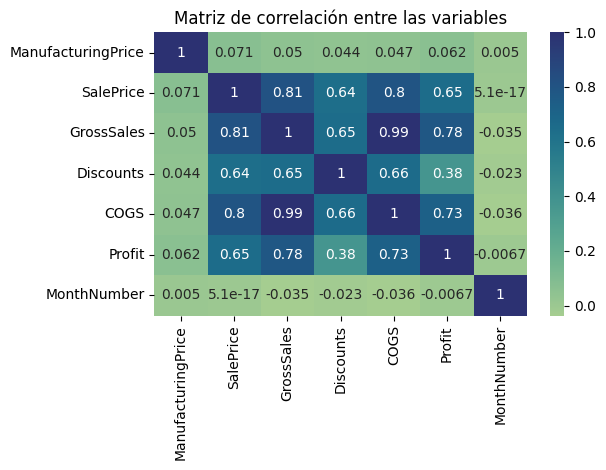

In [ ]:
# df_num = df.select_dtypes(include=np.number)

# X_num = X.select_dtypes(include=np.number)
# X_cat = X.select_dtypes(include='object')

# Matriz de correlación
# df.corr(numeric_only=True)

plt.title('Matriz de correlación entre las variables')
sns.heatmap(X.corr(numeric_only=True), annot=True, cmap="crest")
plt.tight_layout()

In [ ]:
%%capture
!pip install ydata-profiling

In [ ]:
from ydata_profiling import ProfileReport

# Visualización con ProfileReport
profile = ProfileReport(df, title="Reporte analítico de datos de Financials")
profile.to_file("Financials.html")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 30.05it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Codificación de variables categóricas

**Codificación One-Hot (Dummy variables)**

In [ ]:
# Construcción de un pipeline para los atributos numéricos
'''
  Se utiliza el escalador robusto basado en la mediana pues las distribuciones de cada
  variable no es gaussiana y tienen bastantes valores atípicos.
'''
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('st_scaler', RobustScaler()),
])

In [ ]:
# Transormador para codificar únicamente las columnas categóricas y devolver un DataFrame
#
class CustomOneHotEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self._oh = OneHotEncoder(sparse_output=False)
        self._columns = None

    def fit(self, X, y=None):
        X_cat = X.select_dtypes(include=['object'])
        self._columns = pd.get_dummies(X_cat).columns
        self._oh.fit(X_cat)
        return self

    def transform(self, X, y=None):
        X_copy = X.copy()
        X_cat = X_copy.select_dtypes(include=['object'])
        X_cat_oh = self._oh.transform(X_cat)
        X_cat_oh = pd.DataFrame(X_cat_oh,
                                columns=self._columns,
                                index=X_copy.index)
        X_copy.drop(list(X_cat), axis=1, inplace=True)
        return X_copy.join(X_cat_oh)

In [ ]:
# Transofrmador que prepara todo el conjunto de datos llamando pipelines y transformadores personalizados
#
class DataFramePreparer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self._full_pipeline = None
        self._columns = None

    def fit(self, X, y=None):
        num_attribs = list(X.select_dtypes(exclude=['object']))
        cat_attribs = list(X.select_dtypes(include=['object']))
        self._full_pipeline = ColumnTransformer([
                ("num", num_pipeline, num_attribs),
                ("cat", CustomOneHotEncoder(), cat_attribs),
        ])
        self._full_pipeline.fit(X)
        self._columns = pd.get_dummies(X).columns
        return self

    def transform(self, X, y=None):
        X_copy = X.copy()
        X_prep = self._full_pipeline.transform(X_copy)
        return pd.DataFrame(X_prep,
                            columns=self._columns,
                            index=X_copy.index)

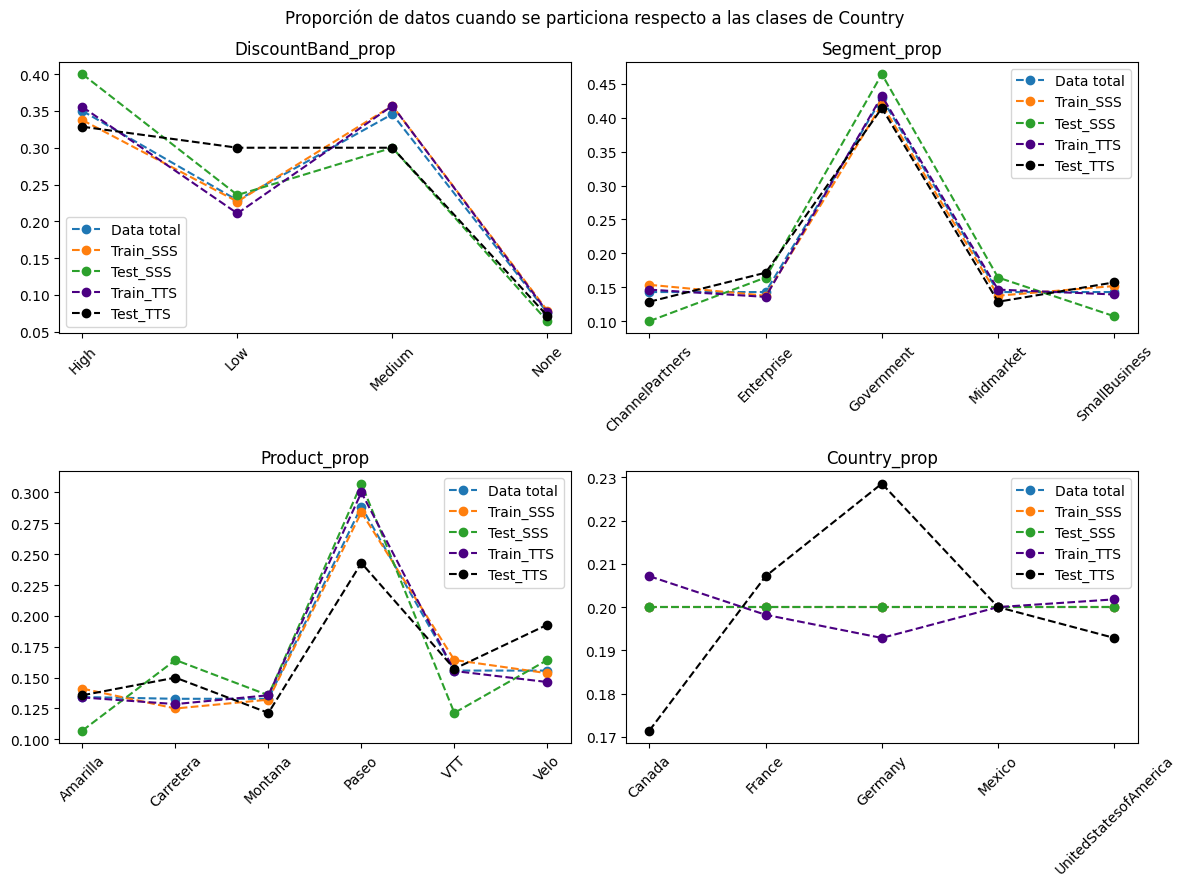

In [ ]:
'''
  Estudio de la proporción de datos en la partición cuando estos tienen variables categóricas
  Se compara train_test_split y StratifiedShuffleSplit haciendo la partición manteniendo la proporción
  de clases en una variable categórica (col_name)
'''

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

col_name = 'Country'
for train_index, test_index in split.split(df, df[col_name]):
  X_train, y_train = X.loc[train_index], y.loc[train_index]     # Entrenamiento (80%)
  X_test, y_test = X.loc[test_index], y.loc[test_index]         # Prueba (20%)

X_train_, X_test_, y_train_, y_test_ = train_test_split(X, y, test_size=0.2, random_state=42)

# Proporción de datos para las variables categóricas que tienen unas clases específicas
#
fig, axes = plt.subplots(2,2, figsize=(12,9))
fig.suptitle('Proporción de datos cuando se particiona respecto a las clases de %s' %col_name)

cat_features = ['DiscountBand', 'Segment', 'Product', 'Country']
for i in range(2):
  for j in range(2):
    axes[i,j].set_title(f'{cat_features[i*2+j]}_prop')
    axes[i,j].plot(X.groupby(cat_features[i*2+j]).size()/len(X), 'o--', label='Data total')
    axes[i,j].plot(X_train.groupby(cat_features[i*2+j]).size()/len(X_train), 'o--', label='Train_SSS')
    axes[i,j].plot(X_test.groupby(cat_features[i*2+j]).size()/len(X_test), 'o--', label='Test_SSS')
    axes[i,j].plot(X_train_.groupby(cat_features[i*2+j]).size()/len(X_train_), 'o--', c='indigo', label='Train_TTS')
    axes[i,j].plot(X_test_.groupby(cat_features[i*2+j]).size()/len(X_test_), 'o--', c='black', label='Test_TTS')
    axes[i,j].tick_params(axis='x', rotation=45)
    axes[i,j].legend()

fig.tight_layout()

In [ ]:
transf = DataFramePreparer()
transf.fit(df)
data = transf.transform(df)

X_scaled = data.drop('UnitsSold', axis=1)
y_scaled = data['UnitsSold']

X_train, y_train = X_scaled.loc[train_index], y_scaled.loc[train_index]     # Entrenamiento (80%)
X_test, y_test = X_scaled.loc[test_index], y_scaled.loc[test_index]         # Prueba (20%)

X_train

,ManufacturingPrice,SalePrice,GrossSales,Discounts,COGS,Profit,MonthNumber,Segment_Channel Partners,Segment_Enterprise,Segment_Government,...,Product_ Amarilla,Product_ Carretera,Product_ Montana,Product_ Paseo,Product_ VTT,Product_ Velo,DiscountBand_ High,DiscountBand_ Low,DiscountBand_ Medium,DiscountBand_ None
410,-0.020408,-0.045139,-0.102063,-0.103725,-0.060691,-0.354307,0.666667,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
374,0.000000,0.972222,2.675577,4.591539,2.488240,2.755726,-0.666667,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
331,-0.020408,0.364583,1.049255,1.584227,1.165364,-0.937609,0.444444,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
627,-0.028571,0.972222,1.570213,4.898380,1.476135,0.137278,0.222222,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
282,-0.020408,-0.045139,-0.107628,-0.138169,-0.065058,-0.353820,0.222222,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,-0.020408,0.972222,0.224054,0.517649,0.243550,-0.092476,0.000000,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
357,-0.020408,-0.045139,-0.132109,-0.163737,-0.084271,-0.430070,-1.555556,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
176,-0.020408,-0.017361,-0.028723,-0.087244,-0.009224,-0.015401,0.222222,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
443,-0.028571,-0.045139,-0.131226,-0.159291,-0.083578,-0.429513,0.666667,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### Modelos de regresión de skLearn

In [ ]:
#@title Entrenamiento, hiperparámetros y predicciones
linear = LinearRegression()     # Modelo simple sin penalización

# Los siguientes modelos sólo manejan el hiperparámetro de la tasa de aprendizaje
ridge = Ridge()
lasso = Lasso()
elastic_net = ElasticNet()

# Búsqueda de mejores hiperparámetros
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
param_grid_elastic_net = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9]
}

grid_ridge = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_lasso = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_median_absolute_error')
grid_elastic_net = GridSearchCV(elastic_net, param_grid_elastic_net, cv=5, scoring='neg_median_absolute_error')

# Etapa de entrenamiento
linear.fit(X_train, y_train)
grid_ridge.fit(X_train, y_train)
grid_lasso.fit(X_train, y_train)
grid_elastic_net.fit(X_train, y_train)

print('Mejores hiperparámetros de modelos regularizados: \n')
print('-> Ridge:', grid_ridge.best_params_)
print('-> Lasso:', grid_lasso.best_params_)
print('-> Elastic_net:', grid_elastic_net.best_params_)

# Mejores modelos regularizados
best_ridge = grid_ridge.best_estimator_
best_lasso = grid_lasso.best_estimator_
best_elastic_net = grid_elastic_net.best_estimator_

# Predicciones
y_pred_Linear = linear.fit(X_train, y_train).predict(X_test)
y_pred_Ridge = best_ridge.predict(X_test)
y_pred_Lasso = best_lasso.predict(X_test)
y_pred_Elastic_net = best_elastic_net.predict(X_test)

Mejores hiperparámetros de modelos regularizados: 

-> Ridge: {'alpha': 1}
-> Lasso: {'alpha': 0.01}
-> Elastic_net: {'alpha': 0.01, 'l1_ratio': 0.7}


**Nota:** Se probaron varias métricas de ajuste de hiperparámetros, pero en estos modelos no cambian los resultados


In [ ]:
#@title Coeficientes de los modelos simples
importance = pd.DataFrame(
    {'Características': X_train.columns,
     'LinearRegression': np.abs(linear.coef_.flatten()),
     'Ridge': np.abs(best_ridge.coef_.flatten()),
     'Lasso': np.abs(best_lasso.coef_.flatten()),
     'Elastic_net': np.abs(best_elastic_net.coef_.flatten())
     })

importance

,Características,LinearRegression,Ridge,Lasso,Elastic_net
0,ManufacturingPrice,0.001871,0.001918,0.000000,0.000000
1,SalePrice,1.275057,1.249766,1.141991,1.143029
2,GrossSales,0.117236,0.236888,0.630139,0.391680
3,Discounts,0.034271,0.030821,0.026299,0.028804
4,COGS,0.856504,0.475672,0.000000,0.243095
5,Profit,0.036787,0.019436,0.001957,0.016345
6,MonthNumber,0.073772,0.074369,0.062789,0.067623
7,Segment_Channel Partners,0.020874,0.010578,0.000000,0.000000
8,Segment_Enterprise,0.039762,0.016121,0.000000,0.000000
9,Segment_Government,0.039184,0.026690,0.000000,0.000000


In [ ]:
#@title Métricas
# Error cuadrático medio
mse_Linear = mean_squared_error(y_test, y_pred_Linear)
mse_Ridge = mean_squared_error(y_test, y_pred_Ridge)
mse_Lasso = mean_squared_error(y_test, y_pred_Lasso)
mse_Elastic_net = mean_squared_error(y_test, y_pred_Elastic_net)

# Error absoluto medio
mae_Linear = mean_absolute_error(y_test, y_pred_Linear)
mae_Ridge = mean_absolute_error(y_test, y_pred_Ridge)
mae_Lasso = mean_absolute_error(y_test, y_pred_Lasso)
mae_Elastic_net = mean_absolute_error(y_test, y_pred_Elastic_net)

# R^2
r2_Linear = r2_score(y_test, y_pred_Linear)
r2_Ridge = r2_score(y_test, y_pred_Ridge)
r2_Lasso = r2_score(y_test, y_pred_Lasso)
r2_Elastic_net = r2_score(y_test, y_pred_Elastic_net)

# Exactitud
# accuracy_Linear = accuracy_score(y_test, y_pred_Linear)
# accuracy_Ridge = accuracy_score(y_test, y_pred_Ridge)
# accuracy_Lasso = accuracy_score(y_test, y_pred_Lasso)
# accuracy_Elastic_net = accuracy_score(y_test, y_pred_Elastic_net)

compare = pd.DataFrame({
    'Modelo': ['Linear', 'Ridge', 'Lasso', 'Elastic_net'],
    'MSE': [mse_Linear, mse_Ridge, mse_Lasso, mse_Elastic_net],
    'MAE': [mae_Linear, mae_Ridge, mae_Lasso, mae_Elastic_net],
    'R^2': [r2_Linear, r2_Ridge, r2_Lasso, r2_Elastic_net],
    # 'Accuracy': [accuracy_Linear, accuracy_Ridge, accuracy_Lasso, accuracy_Elastic_net]
}).set_index('Modelo')

compare

,MSE,MAE,R^2
Modelo,,,
Linear,0.209942,0.355600,0.399027
Ridge,0.209998,0.354483,0.398864
Lasso,0.213378,0.352408,0.389189
Elastic_net,0.212310,0.351984,0.392246


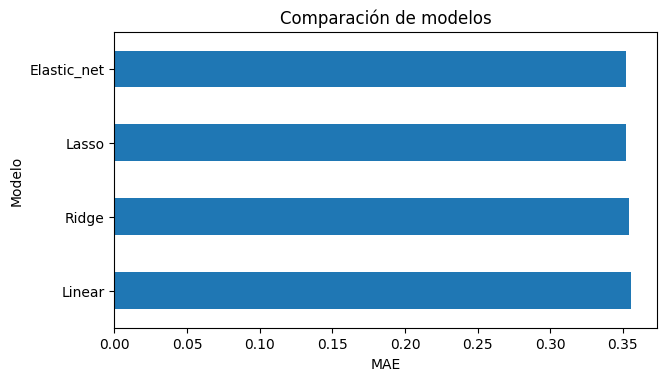

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.84))
compare['MAE'].plot(kind='barh', ax=ax)
ax.set_xlabel('MAE')
ax.set_ylabel('Modelo')
ax.set_title('Comparación de modelos');

### Modelos de Ensembled Learning y más complejos

In [ ]:
#@title Gradient Boosting
model_GBR = GradientBoostingRegressor()   # No regularizado

param_grid_GBR = {
    'n_estimators': [70, 100, 150, 200, 300],   # Número de árboles
    'learning_rate': [0.01, 0.1, 1, 10],
    'max_depth': [3, 4, 5],         # Profundidad máxima de cada árbol. Controla complejidad y sobreajuste.
    'subsample': [0.5, 0.8, 1.0]    # Fracción de muestras para entrenar cada árbol (boostrap sin reemplazo). Reduce sobreajuste.
}

grid_GBR = GridSearchCV(model_GBR, param_grid_GBR, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

# Etapa de entrenamiento
grid_GBR.fit(X_train, y_train)

print('-> Gradient Boosting:', grid_GBR.best_params_)
print('-> Mejor score:', grid_GBR.best_score_)

# Mejores estimadores complejos
best_GBR = grid_GBR.best_estimator_

# Predicciones
y_pred_GBR = best_GBR.predict(X_test)

# Métricas
mse_GBR = mean_squared_error(y_test, y_pred_GBR)
mae_GBR = mean_absolute_error(y_test, y_pred_GBR)
r2_GBR = r2_score(y_test, y_pred_GBR)

print(f'MSE: {mse_GBR}')
print(f'MAE: {mae_GBR}')
print(f'R^2: {r2_GBR}')

-> Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
-> Mejor score: -0.0061320026690017855
MSE: 0.0019971916450552615
MAE: 0.03005595375972498
R^2: 0.9942828918061645


In [ ]:
#@title Árboles de decisión

model_DTR = DecisionTreeRegressor(random_state=42)

param_grid_DTR = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_leaf_nodes': [None, 10, 20, 50]
}

grid_DTR = GridSearchCV(model_DTR, param_grid_DTR, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

# Etapa de entrenamiento
grid_DTR.fit(X_train, y_train)

print('-> Árboles de decisión:', grid_DTR.best_params_)
print('-> Mejor score:', grid_DTR.best_score_)

best_DTR = grid_DTR.best_estimator_

y_pred_DTR = best_DTR.predict(X_test)

mse_DTR = mean_squared_error(y_test, y_pred_DTR)
mae_DTR = mean_absolute_error(y_test, y_pred_DTR)
r2_DTR = r2_score(y_test, y_pred_DTR)

print(f'MSE: {mse_DTR}')
print(f'MAE: {mae_DTR}')
print(f'R^2: {r2_DTR}')

-> Árboles de decisión: {'max_depth': None, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
-> Mejor score: -0.008349253240257938
MSE: 0.008673349304204391
MAE: 0.047467330177610546
R^2: 0.9751718987520135


In [ ]:
#@title LightGBM - Crecimiento de árboles por hojas

model_LGBM = lgb.LGBMRegressor()

param_grid_LGBM = {
    'num_leaves': [10, 20],         # Número máximo de hojas en cada árbol
    'learning_rate': [0.01, 0.05, 1, 10],
    'n_estimators': [100, 200, 300],
    'subsample': [0.1, 0.2, 0.3, 0.5],    # Fracción de muestras usadas para entrenar cada árbol. Reduce sobreajuste introduciendo aleatoriedad.
    'reg_alpha': [0, 0.01, 0.1],          # Regularización L1 (Lasso)
    'reg_lambda': [0.005, 0.01, 0.05]     # Regularización L2 (Ridge)
}

grid_LGBM = GridSearchCV(model_LGBM, param_grid_LGBM, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

grid_LGBM.fit(X_train, y_train)

print('-> LightGBM:', grid_LGBM.best_params_)
print('-> Mejor score:', grid_LGBM.best_score_)

best_LGBM = grid_LGBM.best_estimator_

y_pred_LGBM = best_LGBM.predict(X_test)

mse_LGBM = mean_squared_error(y_test, y_pred_LGBM)
mae_LGBM = mean_absolute_error(y_test, y_pred_LGBM)
r2_LGBM = r2_score(y_test, y_pred_LGBM)

print(f'MSE: {mse_LGBM}')
print(f'MAE: {mae_LGBM}')
print(f'R^2: {r2_LGBM}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 810
[LightGBM] [Info] Number of data points in the train set: 560, number of used features: 27
[LightGBM] [Info] Start training from score 0.043918
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [ ]:
#@title Bosques aleatorios

model_RF = RandomForestRegressor(random_state=42)

param_grid_RF = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

grid_RF = GridSearchCV(model_RF, param_grid_RF, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

# Etapa de entrenamiento
grid_RF.fit(X_train, y_train)

print('-> Bosques aleatorios:', grid_RF.best_params_)
print('-> Mejor score:', grid_RF.best_score_)

best_RF = grid_RF.best_estimator_

y_pred_RF = best_RF.predict(X_test)

mse_RF = mean_squared_error(y_test, y_pred_RF)
mae_RF = mean_absolute_error(y_test, y_pred_RF)
r2_RF = r2_score(y_test, y_pred_RF)

print(f'MSE: {mse_RF}')
print(f'MAE: {mae_RF}')
print(f'R^2: {r2_RF}')

-> Bosques aleatorios: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
-> Mejor score: -0.009526605652055254
MSE: 0.0027662417635530238
MAE: 0.02847465307278387
R^2: 0.9920814291949926


In [ ]:
#@title XGBoost

# model_XGB = xgb.XGBRegressor(objective='reg:squarederror')
model_XGB = xgb.XGBRegressor()

param_grid_XGB = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 1],
    'max_depth': [3, 5, 7],
    'subsample': [0.5, 0.8, 1.0],     # Fracción de muestras usadas para entrenar cada árbol. Reduce sobreajuste introduciendo aleatoriedad.
    'reg_alpha': [0, 0.01, 0.1],      # Regularización L1 (Lasso)
    'reg_lambda': [0.01, 0.05, 0.1]   # Regularización L2 (Ridge)
}

grid_XGB = GridSearchCV(model_XGB, param_grid_XGB, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

grid_XGB.fit(X_train, y_train)

print('-> XGBoost:', grid_XGB.best_params_)
print('-> Mejor score:', grid_XGB.best_score_)

best_XGB = grid_XGB.best_estimator_

y_pred_XGB = best_XGB.predict(X_test)

mse_XGB = mean_squared_error(y_test, y_pred_XGB)
mae_XGB = mean_absolute_error(y_test, y_pred_XGB)
r2_XGB = r2_score(y_test, y_pred_XGB)

print(f'MSE: {mse_XGB}')
print(f'MAE: {mae_XGB}')
print(f'R^2: {r2_XGB}')

-> XGBoost: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 0.1, 'subsample': 0.8}
-> Mejor score: -0.0034945030389569283
MSE: 0.0015355564691678413
MAE: 0.02482525176523052
R^2: 0.995604356500433


In [ ]:
#@title Máquinas de soporte vectorial

model_SVR = SVR()

param_grid_SVR = {
    'C': [1, 10, 30, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto'],   # para 'rbf' y 'poly'
}

grid_SVR = GridSearchCV(model_SVR, param_grid_SVR, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

grid_SVR.fit(X_train, y_train)

print('-> Máquinas de soporte vectorial:', grid_SVR.best_params_)
print('-> Mejor score:', grid_SVR.best_score_)

best_SVR = grid_SVR.best_estimator_

y_pred_SVR = best_SVR.predict(X_test)

mse_SVR = mean_squared_error(y_test, y_pred_SVR)
mae_SVR = mean_absolute_error(y_test, y_pred_SVR)
r2_SVR = r2_score(y_test, y_pred_SVR)

print(f'MSE: {mse_SVR}')
print(f'MAE: {mae_SVR}')
print(f'R^2: {r2_SVR}')

-> Máquinas de soporte vectorial: {'C': 30, 'gamma': 'auto', 'kernel': 'rbf'}
-> Mejor score: -0.12416521761682049
MSE: 0.08962763137199777
MAE: 0.20138322881497542
R^2: 0.7434343033731532


### Comparación de todos los modelos

In [ ]:
compare = pd.DataFrame({
    'Modelo': ['Linear', 'Ridge', 'Lasso', 'Elastic_net', 'GradientBoosting', 'DecisionTree', 'LightGBM', 'RandomForest', 'XGBoost', 'SVR'],
    'MSE': [mse_Linear, mse_Ridge, mse_Lasso, mse_Elastic_net, mse_GBR, mse_DTR, mse_LGBM, mse_RF, mse_XGB, mse_SVR],
    'MAE': [mae_Linear, mae_Ridge, mae_Lasso, mae_Elastic_net, mae_GBR, mae_DTR, mae_LGBM, mae_RF, mae_XGB, mae_SVR],
    'R^2': [r2_Linear, r2_Ridge, r2_Lasso, r2_Elastic_net, r2_GBR, r2_DTR, r2_LGBM, r2_RF, r2_XGB, r2_SVR],
}).set_index('Modelo')

compare

,MSE,MAE,R^2
Modelo,,,
Linear,0.209942,0.355600,0.399027
Ridge,0.209998,0.354483,0.398864
Lasso,0.213378,0.352408,0.389189
Elastic_net,0.212310,0.351984,0.392246
GradientBoosting,0.001997,0.030056,0.994283
DecisionTree,0.008673,0.047467,0.975172
LightGBM,0.009638,0.054804,0.972410
RandomForest,0.002766,0.028475,0.992081
XGBoost,0.001536,0.024825,0.995604


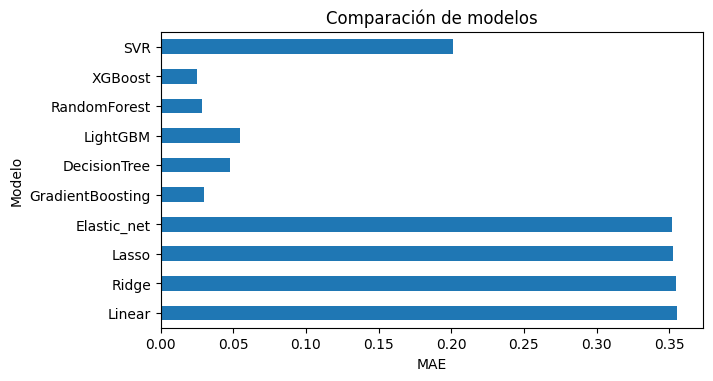

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.84))
compare['MAE'].plot(kind='barh', ax=ax)
ax.set_xlabel('MAE')
ax.set_ylabel('Modelo')
ax.set_title('Comparación de modelos');

### Descomposición en componentes principales

In [ ]:
X_scaled.shape

(700, 27)

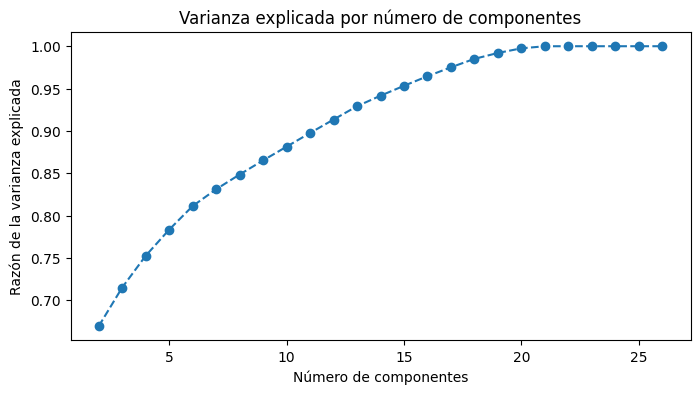

In [ ]:
# PCA con diferentes números de componentes
n_comps = range(2, X_scaled.shape[1])
explained_variances = np.zeros(len(n_comps))

for i in range(len(n_comps)):
    pca = PCA(n_components=n_comps[i])
    X_pca = pca.fit_transform(X_scaled)
    explained_variances[i] = pca.explained_variance_ratio_.sum()

plt.figure(figsize=(8, 4))
plt.plot(n_comps, explained_variances, 'o--')
plt.xlabel('Número de componentes')
plt.ylabel('Razón de la varianza explicada')
plt.title('Varianza explicada por número de componentes')
plt.grid(False)
plt.show()

Con 6 componentes es suficiente para explicar más del 80% de la varianza, por lo que es posible hacer regresiones precisas con esta cantidad de componentes